In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:
PROJECT_ROOT = Path(
    r"C:\Users\sarun\OneDrive\Desktop\cesppl-internship"
)

PROCESSED_DATASET_DIR = (
    PROJECT_ROOT /
    "data" /
    "cesppl_processed"
)

WEEK9_DIR = PROJECT_ROOT / "Week-09"

TRAIN_CSV_PATH = WEEK9_DIR / "train.csv"
VAL_CSV_PATH = WEEK9_DIR / "val.csv"
TEST_CSV_PATH = WEEK9_DIR / "test.csv"

OUTPUT_DIR = WEEK9_DIR / "first_run_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Processed dataset:", PROCESSED_DATASET_DIR)
print("Train CSV:", TRAIN_CSV_PATH)
print("Validation CSV:", VAL_CSV_PATH)
print("Output directory:", OUTPUT_DIR)

Processed dataset: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_processed
Train CSV: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\train.csv
Validation CSV: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\val.csv
Output directory: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs


In [4]:
required_paths = [
    PROCESSED_DATASET_DIR,
    TRAIN_CSV_PATH,
    VAL_CSV_PATH
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Required path was not found:\n{path}"
        )

print("✅ All required dataset and CSV paths were found.")

✅ All required dataset and CSV paths were found.


In [5]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

print("Training rows  :", len(train_df))
print("Validation rows:", len(val_df))

display(train_df.head())
display(val_df.head())

Training rows  : 2530
Validation rows: 543


,filename,class
0,BIN LIFTING/Screenshot_2026-05-31_133130__png.jpg,BIN_LIFTING
1,BIN LIFTING/Screenshot_2026-05-31_133145__png.jpg,BIN_LIFTING
2,BIN LIFTING/Screenshot_2026-05-31_133259__png.jpg,BIN_LIFTING
3,BIN LIFTING/Screenshot_2026-05-31_133312__png.jpg,BIN_LIFTING
4,BIN LIFTING/Screenshot_2026-05-31_133543__png.jpg,BIN_LIFTING


,filename,class
0,BIN LIFTING/Screenshot_2026-05-31_133530__png.jpg,BIN_LIFTING
1,BIN LIFTING/Screenshot_2026-05-31_134530__png.jpg,BIN_LIFTING
2,BIN LIFTING/Screenshot_2026-05-31_134933__png.jpg,BIN_LIFTING
3,BIN LIFTING/Screenshot_2026-05-31_135429__png.jpg,BIN_LIFTING
4,BIN LIFTING/Screenshot_2026-05-31_135528__png.jpg,BIN_LIFTING


In [6]:
REQUIRED_COLUMNS = {"filename", "class"}

if not REQUIRED_COLUMNS.issubset(train_df.columns):
    raise ValueError(
        f"train.csv must contain these columns: {REQUIRED_COLUMNS}"
    )

if not REQUIRED_COLUMNS.issubset(val_df.columns):
    raise ValueError(
        f"val.csv must contain these columns: {REQUIRED_COLUMNS}"
    )

if train_df[["filename", "class"]].isna().any().any():
    raise ValueError("Missing values were found in train.csv.")

if val_df[["filename", "class"]].isna().any().any():
    raise ValueError("Missing values were found in val.csv.")

if train_df["filename"].duplicated().any():
    raise ValueError("Duplicate filenames were found in train.csv.")

if val_df["filename"].duplicated().any():
    raise ValueError("Duplicate filenames were found in val.csv.")

print("✅ CSV structure validated successfully.")

✅ CSV structure validated successfully.


In [7]:
train_filename_set = set(train_df["filename"])
val_filename_set = set(val_df["filename"])

overlap = train_filename_set & val_filename_set

print("Train-validation overlap:", len(overlap))

if overlap:
    raise ValueError(
        "Some images appear in both training and validation."
    )

print("✅ Training and validation files do not overlap.")

Train-validation overlap: 0
✅ Training and validation files do not overlap.


In [8]:
train_classes = sorted(
    train_df["class"].astype(str).unique().tolist()
)

val_classes = sorted(
    val_df["class"].astype(str).unique().tolist()
)

if train_classes != val_classes:
    raise ValueError(
        "Training and validation classes do not match.\n"
        f"Train classes: {train_classes}\n"
        f"Validation classes: {val_classes}"
    )

class_names = train_classes
NUM_CLASSES = len(class_names)

if NUM_CLASSES != 10:
    raise ValueError(
        f"Expected 10 classes, but found {NUM_CLASSES}."
    )

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Number of classes:", NUM_CLASSES)

for class_name, index in class_to_index.items():
    print(f"{index}: {class_name}")

Number of classes: 10
0: BIN_LIFTING
1: BIN_WASHING
2: GATE_MEETING
3: LFC
4: MANUAL_BEACH_CLEANING
5: MECHANICAL_SWEEPING
6: MECHANIZED_BEACH_CLEANING
7: PRIMARY_COLLECTION
8: ROAD_SWEEPING
9: SECONDARY_VEHICLES


In [9]:
CLASS_MAPPING_PATH = OUTPUT_DIR / "class_mapping.json"

with open(
    CLASS_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        class_to_index,
        file,
        indent=4
    )

print("Saved class mapping:", CLASS_MAPPING_PATH)

Saved class mapping: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\class_mapping.json


In [10]:
def create_absolute_path(relative_filename):
    return (
        PROCESSED_DATASET_DIR /
        Path(str(relative_filename))
    ).resolve().as_posix()


train_df["absolute_path"] = train_df["filename"].apply(
    create_absolute_path
)

val_df["absolute_path"] = val_df["filename"].apply(
    create_absolute_path
)

train_df["label_index"] = train_df["class"].map(
    class_to_index
)

val_df["label_index"] = val_df["class"].map(
    class_to_index
)

display(
    train_df[
        ["filename", "class", "label_index", "absolute_path"]
    ].head()
)

,filename,class,label_index,absolute_path
0,BIN LIFTING/Screenshot_2026-05-31_133130__png.jpg,BIN_LIFTING,0,C:/Users/sarun/OneDrive/Desktop/cesppl-interns...
1,BIN LIFTING/Screenshot_2026-05-31_133145__png.jpg,BIN_LIFTING,0,C:/Users/sarun/OneDrive/Desktop/cesppl-interns...
2,BIN LIFTING/Screenshot_2026-05-31_133259__png.jpg,BIN_LIFTING,0,C:/Users/sarun/OneDrive/Desktop/cesppl-interns...
3,BIN LIFTING/Screenshot_2026-05-31_133312__png.jpg,BIN_LIFTING,0,C:/Users/sarun/OneDrive/Desktop/cesppl-interns...
4,BIN LIFTING/Screenshot_2026-05-31_133543__png.jpg,BIN_LIFTING,0,C:/Users/sarun/OneDrive/Desktop/cesppl-interns...


In [11]:
missing_train_files = [
    path
    for path in train_df["absolute_path"]
    if not Path(path).exists()
]

missing_val_files = [
    path
    for path in val_df["absolute_path"]
    if not Path(path).exists()
]

print("Missing training files  :", len(missing_train_files))
print("Missing validation files:", len(missing_val_files))

if missing_train_files:
    print("Example missing training file:")
    print(missing_train_files[0])

    raise FileNotFoundError(
        "Some training images listed in train.csv were not found."
    )

if missing_val_files:
    print("Example missing validation file:")
    print(missing_val_files[0])

    raise FileNotFoundError(
        "Some validation images listed in val.csv were not found."
    )

print("✅ Every image listed in the CSV files exists.")

Missing training files  : 0
Missing validation files: 0
✅ Every image listed in the CSV files exists.


In [12]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE

print("Image size :", (IMG_HEIGHT, IMG_WIDTH))
print("Batch size:", BATCH_SIZE)
print("Epochs    :", EPOCHS)

Image size : (224, 224)
Batch size: 32
Epochs    : 10


In [13]:
def load_and_resize_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        size=[IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)

    return image, label

In [15]:
train_paths = train_df["absolute_path"].astype(str).to_numpy()
train_labels = train_df["label_index"].astype(np.int32).to_numpy()

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=SEED,
    reshuffle_each_iteration=True
)

train_dataset = train_dataset.map(
    load_and_resize_image,
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

print("✅ Training dataset created.")

✅ Training dataset created.


In [16]:
val_paths = val_df["absolute_path"].astype(str).to_numpy()
val_labels = val_df["label_index"].astype(np.int32).to_numpy()

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_dataset = val_dataset.map(
    load_and_resize_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.prefetch(
    AUTOTUNE
)

print("✅ Validation dataset created.")

✅ Validation dataset created.


In [17]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype      :", images.dtype)
    print("Minimum value    :", tf.reduce_min(images).numpy())
    print("Maximum value    :", tf.reduce_max(images).numpy())
    print("First labels     :", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype      : <dtype: 'float32'>
Minimum value    : 0.0
Maximum value    : 255.0
First labels     : [2 1 1 1 7 1 3 4 6 6]


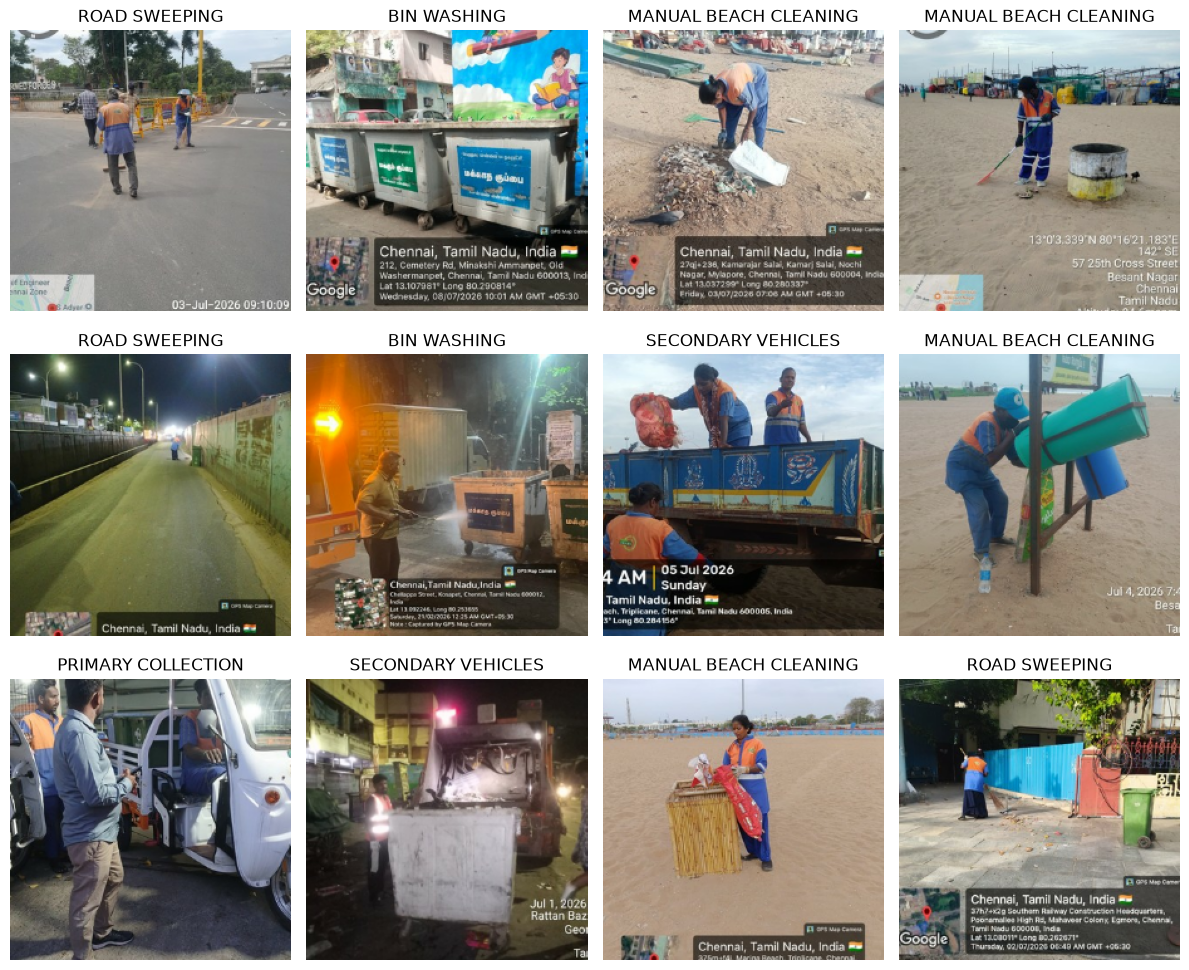

In [18]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):
    number_of_images = min(12, images.shape[0])

    for index in range(number_of_images):
        plt.subplot(3, 4, index + 1)

        image = tf.cast(
            tf.clip_by_value(
                images[index],
                0,
                255
            ),
            tf.uint8
        )

        plt.imshow(image.numpy())
        plt.title(
            class_names[int(labels[index].numpy())]
            .replace("_", " ")
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),
        tf.keras.layers.RandomRotation(
            0.08
        ),
        tf.keras.layers.RandomZoom(
            0.10
        ),
        tf.keras.layers.RandomContrast(
            0.10
        )
    ],
    name="data_augmentation"
)

print("✅ Data augmentation block created.")

✅ Data augmentation block created.


In [20]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    )
)

base_model.trainable = False

print("Base model trainable:", base_model.trainable)
print("Number of base-model layers:", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model trainable: False
Number of base-model layers: 238


In [21]:
inputs = tf.keras.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ),
    name="input_image"
)

x = data_augmentation(inputs)

x = tf.keras.layers.Lambda(
    tf.keras.applications.efficientnet.preprocess_input,
    name="efficientnet_preprocessing"
)(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.3,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="cesppl_efficientnetb0_smoke_test"
)

model.summary()

Model: "cesppl_efficientnetb0_smoke_test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocessing      │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
trainable_base_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Trainable layers inside EfficientNetB0:",
    len(trainable_base_layers)
)

if trainable_base_layers:
    raise ValueError(
        "EfficientNetB0 is not fully frozen."
    )

print("✅ EfficientNetB0 is fully frozen.")

Trainable layers inside EfficientNetB0: 0
✅ EfficientNetB0 is fully frozen.


In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.


In [24]:
BEST_MODEL_PATH = (
    OUTPUT_DIR /
    "best_smoke_test_model.keras"
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    model_checkpoint
]

print("✅ Callbacks prepared.")

✅ Callbacks prepared.


In [25]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


c:\Users\sarun\anaconda3\anaconda3\envs\cesppl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.6360 - loss: 1.1722
Epoch 1: val_loss improved from None to 0.49105, saving model to C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\best_smoke_test_model.keras

Epoch 1: finished saving model to C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\best_smoke_test_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 325ms/step - accuracy: 0.6360 - loss: 1.1722 - val_accuracy: 0.8895 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8692 - loss: 0.5221
Epoch 2: val_loss improved from 0.49105 to 0.32438, saving model to C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\best_smoke_test_model.keras

Epoch 2: finished saving model to C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\best_smoke_test_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 333ms/step - accuracy: 0.8692 - loss: 0.5221 - 

In [26]:
history_df = pd.DataFrame(history.history)

best_val_accuracy = history_df["val_accuracy"].max()
best_val_loss = history_df["val_loss"].min()

best_val_accuracy_epoch = (
    history_df["val_accuracy"].idxmax() + 1
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation accuracy epoch: "
    f"{best_val_accuracy_epoch}"
)

print(
    f"Lowest validation loss: "
    f"{best_val_loss:.4f}"
)

Best validation accuracy: 95.58%
Best validation accuracy epoch: 9
Lowest validation loss: 0.1692


In [27]:
HISTORY_CSV_PATH = (
    OUTPUT_DIR /
    "training_history.csv"
)

history_df.to_csv(
    HISTORY_CSV_PATH,
    index=False
)

print("Saved:", HISTORY_CSV_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\training_history.csv


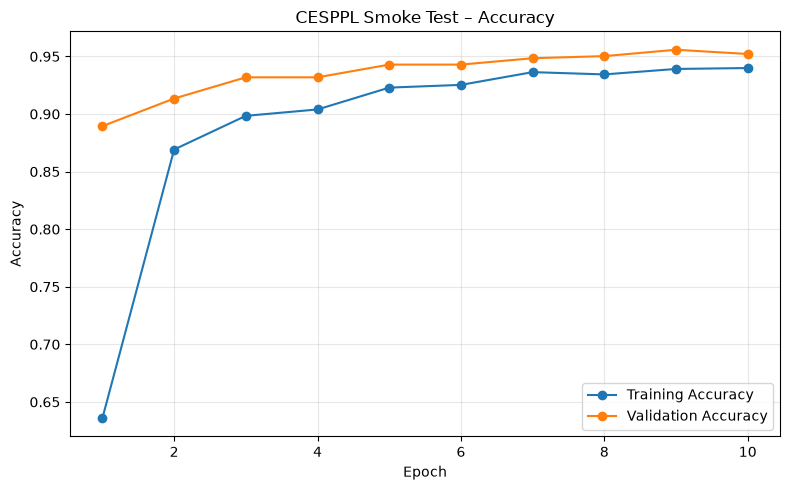

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\smoke_test_accuracy.png


In [28]:
epochs_completed = range(
    1,
    len(history_df) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_completed,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CESPPL Smoke Test – Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

ACCURACY_PLOT_PATH = (
    OUTPUT_DIR /
    "smoke_test_accuracy.png"
)

plt.savefig(
    ACCURACY_PLOT_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ACCURACY_PLOT_PATH)

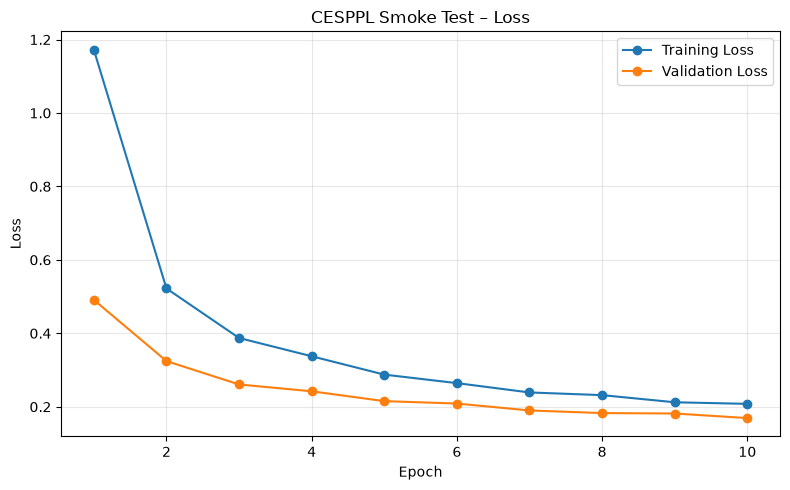

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\smoke_test_loss.png


In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_completed,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CESPPL Smoke Test – Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

LOSS_PLOT_PATH = (
    OUTPUT_DIR /
    "smoke_test_loss.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_PLOT_PATH)

In [30]:
validation_loss, validation_accuracy = model.evaluate(
    val_dataset,
    verbose=1
)

print(
    f"Validation Loss: "
    f"{validation_loss:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.9521 - loss: 0.1692
Validation Loss: 0.1692
Validation Accuracy: 95.21%


In [31]:
validation_probabilities = model.predict(
    val_dataset,
    verbose=1
)

predicted_labels = np.argmax(
    validation_probabilities,
    axis=1
)

true_labels = val_df["label_index"].to_numpy()

print("Prediction shape:", validation_probabilities.shape)
print("True labels     :", true_labels.shape)
print("Predicted labels:", predicted_labels.shape)

if len(predicted_labels) != len(true_labels):
    raise ValueError(
        "Prediction count does not match validation label count."
    )

print("✅ Validation predictions generated successfully.")

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 332ms/step
Prediction shape: (543, 10)
True labels     : (543,)
Predicted labels: (543,)
✅ Validation predictions generated successfully.


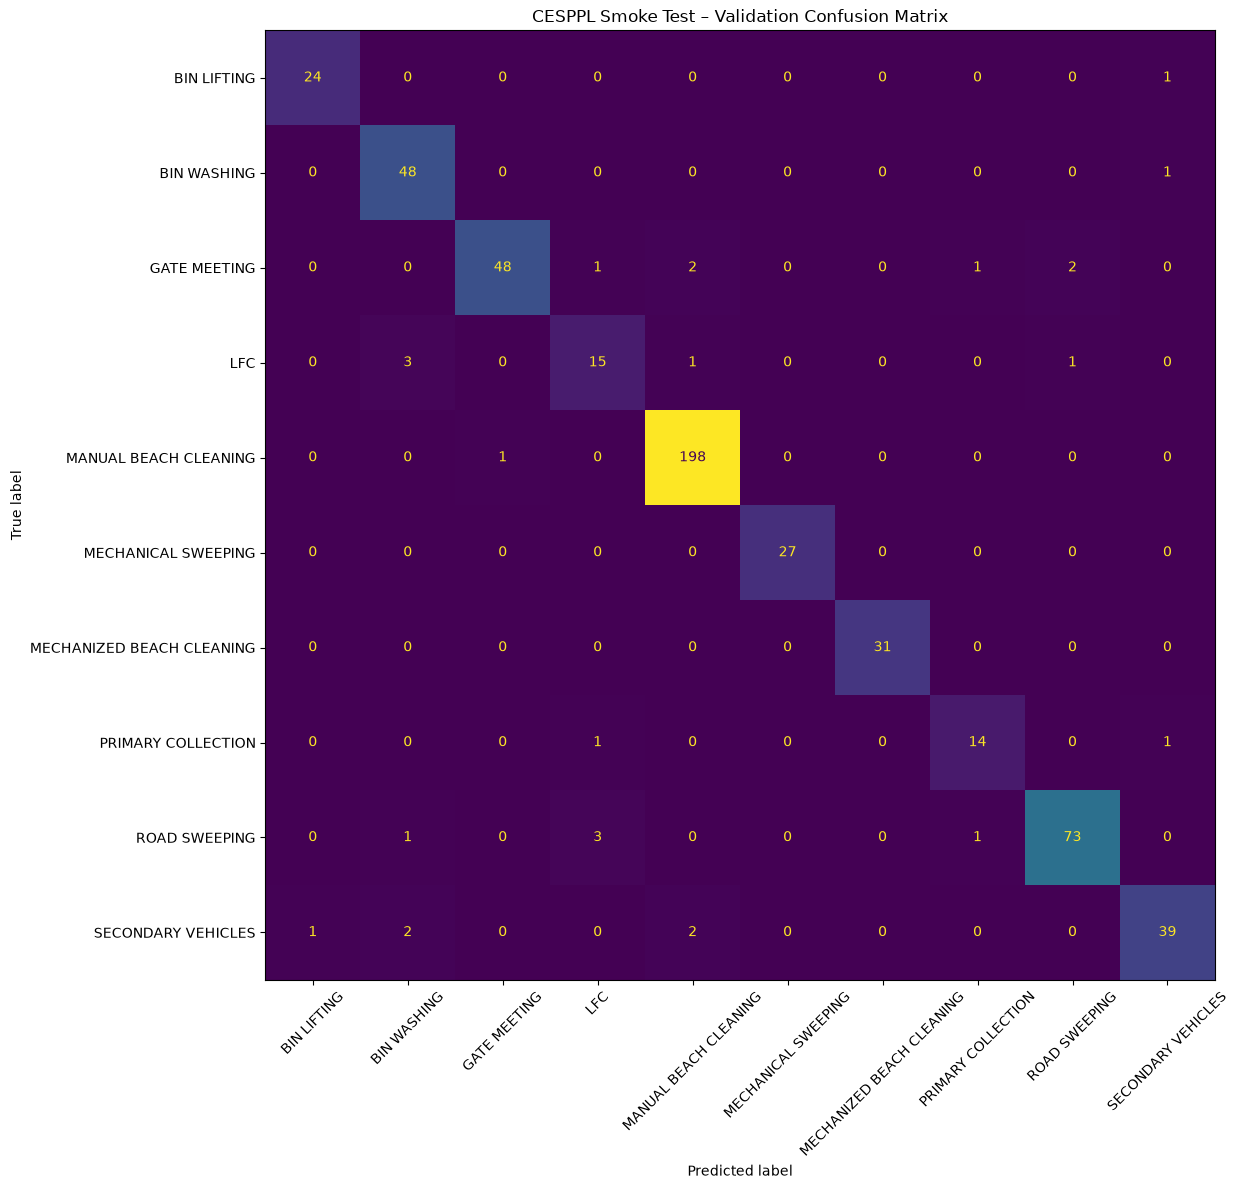

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\smoke_test_confusion_matrix.png


In [32]:
confusion_matrix_values = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=list(range(NUM_CLASSES))
)

display_labels = [
    name.replace("_", " ")
    for name in class_names
]

figure, axis = plt.subplots(
    figsize=(14, 12)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=display_labels
)

display_cm.plot(
    ax=axis,
    xticks_rotation=45,
    values_format="d",
    colorbar=False
)

plt.title(
    "CESPPL Smoke Test – Validation Confusion Matrix"
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR /
    "smoke_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", CONFUSION_MATRIX_PATH)

In [33]:
report_dictionary = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dictionary
).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
BIN_LIFTING,0.9600,0.9600,0.9600,25.0000
BIN_WASHING,0.8889,0.9796,0.9320,49.0000
GATE_MEETING,0.9796,0.8889,0.9320,54.0000
LFC,0.7500,0.7500,0.7500,20.0000
MANUAL_BEACH_CLEANING,0.9754,0.9950,0.9851,199.0000
MECHANICAL_SWEEPING,1.0000,1.0000,1.0000,27.0000
MECHANIZED_BEACH_CLEANING,1.0000,1.0000,1.0000,31.0000
PRIMARY_COLLECTION,0.8750,0.8750,0.8750,16.0000
ROAD_SWEEPING,0.9605,0.9359,0.9481,78.0000
SECONDARY_VEHICLES,0.9286,0.8864,0.9070,44.0000


In [34]:
CLASSIFICATION_REPORT_PATH = (
    OUTPUT_DIR /
    "validation_classification_report.csv"
)

report_df.to_csv(
    CLASSIFICATION_REPORT_PATH
)

print("Saved:", CLASSIFICATION_REPORT_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\validation_classification_report.csv


In [35]:
per_class_report_df = report_df.loc[
    class_names,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

per_class_report_df = per_class_report_df.sort_values(
    "recall",
    ascending=False
)

print("Classes sorted by validation recall:")

display(
    per_class_report_df.round(4)
)

Classes sorted by validation recall:


,precision,recall,f1-score,support
MECHANIZED_BEACH_CLEANING,1.0000,1.0000,1.0000,31.0
MECHANICAL_SWEEPING,1.0000,1.0000,1.0000,27.0
MANUAL_BEACH_CLEANING,0.9754,0.9950,0.9851,199.0
BIN_WASHING,0.8889,0.9796,0.9320,49.0
BIN_LIFTING,0.9600,0.9600,0.9600,25.0
ROAD_SWEEPING,0.9605,0.9359,0.9481,78.0
GATE_MEETING,0.9796,0.8889,0.9320,54.0
SECONDARY_VEHICLES,0.9286,0.8864,0.9070,44.0
PRIMARY_COLLECTION,0.8750,0.8750,0.8750,16.0
LFC,0.7500,0.7500,0.7500,20.0


In [36]:
confusion_rows = []

for true_index in range(NUM_CLASSES):
    for predicted_index in range(NUM_CLASSES):

        if true_index == predicted_index:
            continue

        count = int(
            confusion_matrix_values[
                true_index,
                predicted_index
            ]
        )

        if count > 0:
            confusion_rows.append({
                "true_class": class_names[true_index],
                "predicted_class": class_names[predicted_index],
                "count": count
            })

confusions_df = pd.DataFrame(confusion_rows)

if confusions_df.empty:
    print("No incorrect predictions were found.")
else:
    confusions_df = confusions_df.sort_values(
        "count",
        ascending=False
    ).reset_index(drop=True)

    display(confusions_df.head(15))

,true_class,predicted_class,count
0,ROAD_SWEEPING,LFC,3
1,LFC,BIN_WASHING,3
2,SECONDARY_VEHICLES,MANUAL_BEACH_CLEANING,2
3,SECONDARY_VEHICLES,BIN_WASHING,2
4,GATE_MEETING,ROAD_SWEEPING,2
5,GATE_MEETING,MANUAL_BEACH_CLEANING,2
6,BIN_WASHING,SECONDARY_VEHICLES,1
7,BIN_LIFTING,SECONDARY_VEHICLES,1
8,GATE_MEETING,PRIMARY_COLLECTION,1
9,GATE_MEETING,LFC,1


In [37]:
CONFUSIONS_CSV_PATH = (
    OUTPUT_DIR /
    "largest_validation_confusions.csv"
)

if confusions_df.empty:
    pd.DataFrame(
        columns=[
            "true_class",
            "predicted_class",
            "count"
        ]
    ).to_csv(
        CONFUSIONS_CSV_PATH,
        index=False
    )
else:
    confusions_df.to_csv(
        CONFUSIONS_CSV_PATH,
        index=False
    )

print("Saved:", CONFUSIONS_CSV_PATH)

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\largest_validation_confusions.csv


In [38]:
SUMMARY_PATH = (
    OUTPUT_DIR /
    "smoke_test_summary.txt"
)

summary_text = f"""
CESPPL Week 9 Smoke Test

Training images: {len(train_df)}
Validation images: {len(val_df)}
Number of classes: {NUM_CLASSES}

Backbone: EfficientNetB0
Backbone frozen: Yes
Dropout: 0.3
Optimizer: Adam
Initial learning rate: 1e-3
Maximum epochs: {EPOCHS}
Epochs completed: {len(history_df)}

Best validation accuracy: {best_val_accuracy * 100:.2f}%
Final restored validation accuracy: {validation_accuracy * 100:.2f}%
Validation loss: {validation_loss:.4f}

Purpose:
This was a low-cost smoke test intended to verify the complete
CESPPL image-classification pipeline. It was not intended to produce
the final model or maximum possible accuracy.
""".strip()

SUMMARY_PATH.write_text(
    summary_text,
    encoding="utf-8"
)

print(summary_text)
print("\nSaved:", SUMMARY_PATH)

CESPPL Week 9 Smoke Test

Training images: 2530
Validation images: 543
Number of classes: 10

Backbone: EfficientNetB0
Backbone frozen: Yes
Dropout: 0.3
Optimizer: Adam
Initial learning rate: 1e-3
Maximum epochs: 10
Epochs completed: 10

Best validation accuracy: 95.58%
Final restored validation accuracy: 95.21%
Validation loss: 0.1692

Purpose:
This was a low-cost smoke test intended to verify the complete
CESPPL image-classification pipeline. It was not intended to produce
the final model or maximum possible accuracy.

Saved: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-09\first_run_outputs\smoke_test_summary.txt


In [39]:
required_output_files = [
    CLASS_MAPPING_PATH,
    BEST_MODEL_PATH,
    HISTORY_CSV_PATH,
    ACCURACY_PLOT_PATH,
    LOSS_PLOT_PATH,
    CONFUSION_MATRIX_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSIONS_CSV_PATH,
    SUMMARY_PATH
]

print("========== Output Verification ==========")

missing_outputs = []

for file_path in required_output_files:
    if file_path.exists():
        print(f"FOUND   - {file_path.name}")
    else:
        print(f"MISSING - {file_path.name}")
        missing_outputs.append(file_path)

if missing_outputs:
    raise FileNotFoundError(
        "Some smoke-test output files are missing."
    )

print("\n✅ All smoke-test outputs were created.")

========== Output Verification ==========
FOUND   - class_mapping.json
FOUND   - best_smoke_test_model.keras
FOUND   - training_history.csv
FOUND   - smoke_test_accuracy.png
FOUND   - smoke_test_loss.png
FOUND   - smoke_test_confusion_matrix.png
FOUND   - validation_classification_report.csv
FOUND   - largest_validation_confusions.csv
FOUND   - smoke_test_summary.txt

✅ All smoke-test outputs were created.


# Week 9 Friday Conclusion

## Smoke-Test Objective

The purpose of this experiment was to confirm that the CESPPL machine-learning pipeline works from beginning to end. It was not intended to produce the final model or maximum validation accuracy.

## Completed Work

- Loaded the frozen `train.csv` and `val.csv` split files.
- Created TensorFlow datasets using `tf.data.Dataset.from_tensor_slices`.
- Loaded, decoded and resized images through a mapping function.
- Applied standard image augmentation inside the model.
- Used an ImageNet-pretrained EfficientNetB0 backbone.
- Kept the EfficientNetB0 backbone fully frozen.
- Added global average pooling, dropout of 0.3 and a ten-class softmax output layer.
- Compiled the model using Adam with a learning rate of `1e-3`.
- Trained for a maximum of ten epochs with EarlyStopping and ReduceLROnPlateau.
- Evaluated the model on the validation split.
- Plotted accuracy and loss curves.
- Generated a validation confusion matrix and classification report.
- Compared the main class confusions with the Week 9 data observations.

## Interpretation

This was a pipeline smoke test. A moderate validation result is sufficient if image loading, augmentation, training, prediction and evaluation all work correctly.

The final test split was not used during this experiment. Proper model development and tuning will begin in Week 10 while continuing to use the same frozen train, validation and test CSV files.